  СРАВНЕНИЕ 1D И 2D РЕШЕНИЙ ПРЯМОЙ ЗАДАЧИ МТЗ
  Модель: грабен с проводящим заполнением


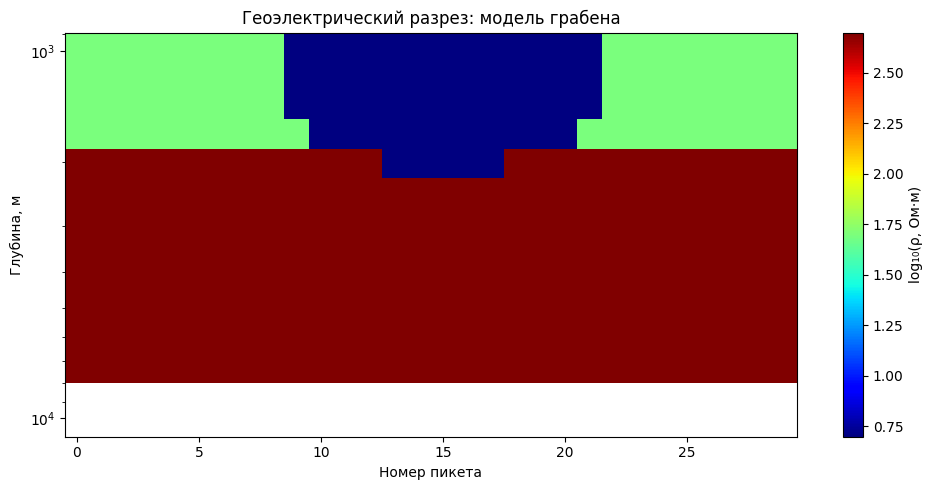

Расчёт для 30 пикетов, 50 периодов...
SimPEG не установлен. Используется эмуляция 2D решения.

  ТАБЛИЦА НЕВЯЗОК: Аналитическое 1D vs 2D
Период, с    невязка Zxy     невязка Zyx     Среднее        
----------------------------------------------------------------------
0.0010       0.768226        2.443400        1.605813       
0.0032       0.764894        2.549383        1.657139       
0.0105       0.785481        2.232215        1.508848       
0.0339       0.795927        1.987123        1.391525       
0.1099       0.800610        1.901480        1.351045       
0.3556       0.770943        2.464018        1.617480       
1.1514       0.766629        3.405943        2.086286       
3.7276       0.772884        3.007881        1.890383       
12.0679      0.746254        1.947419        1.346837       
39.0694      0.802200        1.161886        0.982043       
----------------------------------------------------------------------
Среднее         0.777405        2.310075        1.

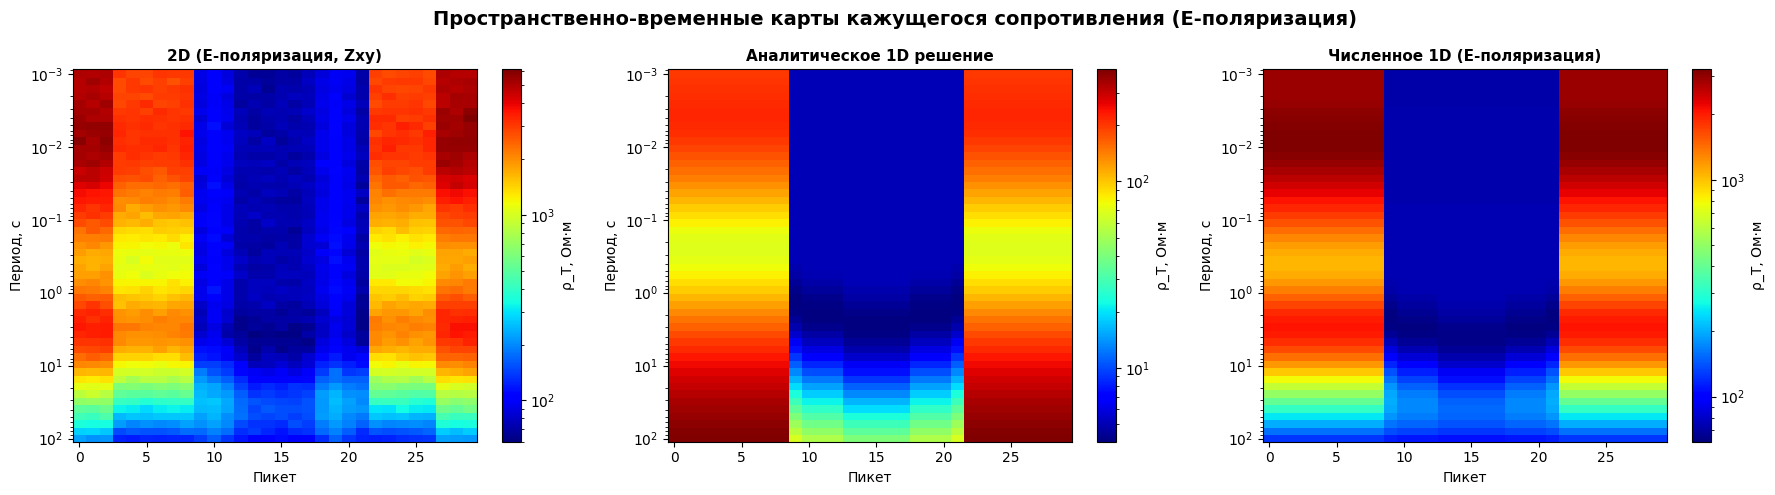

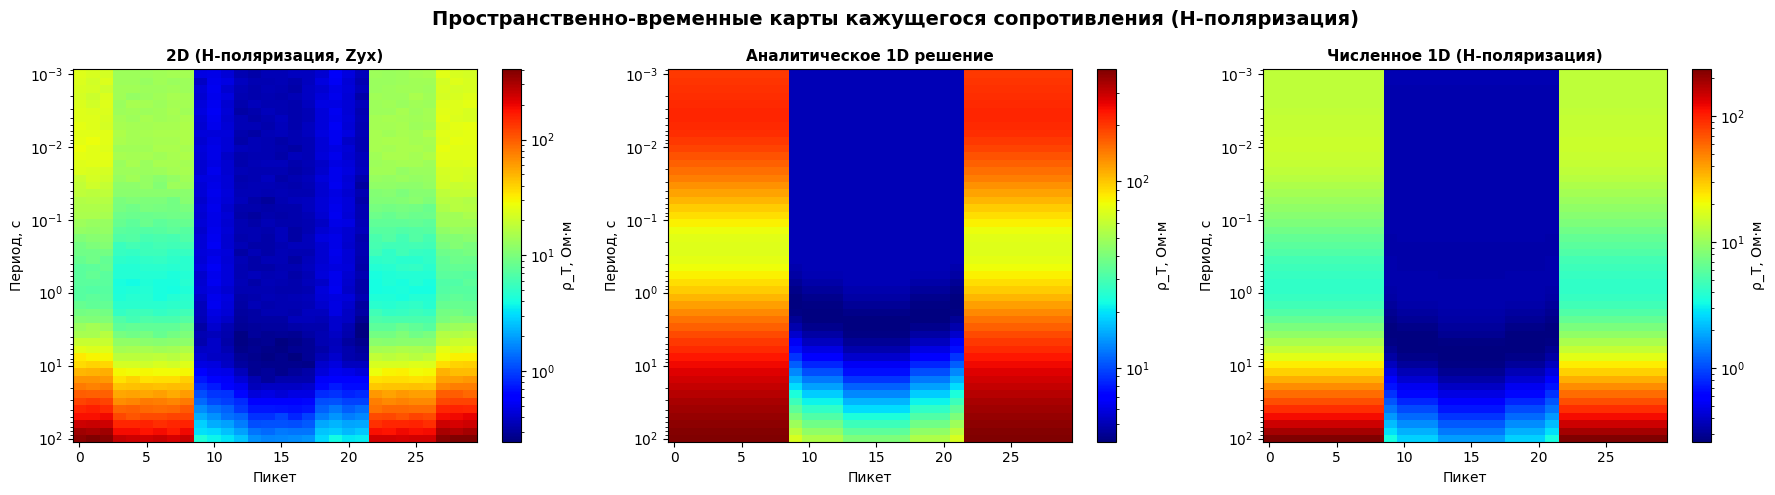

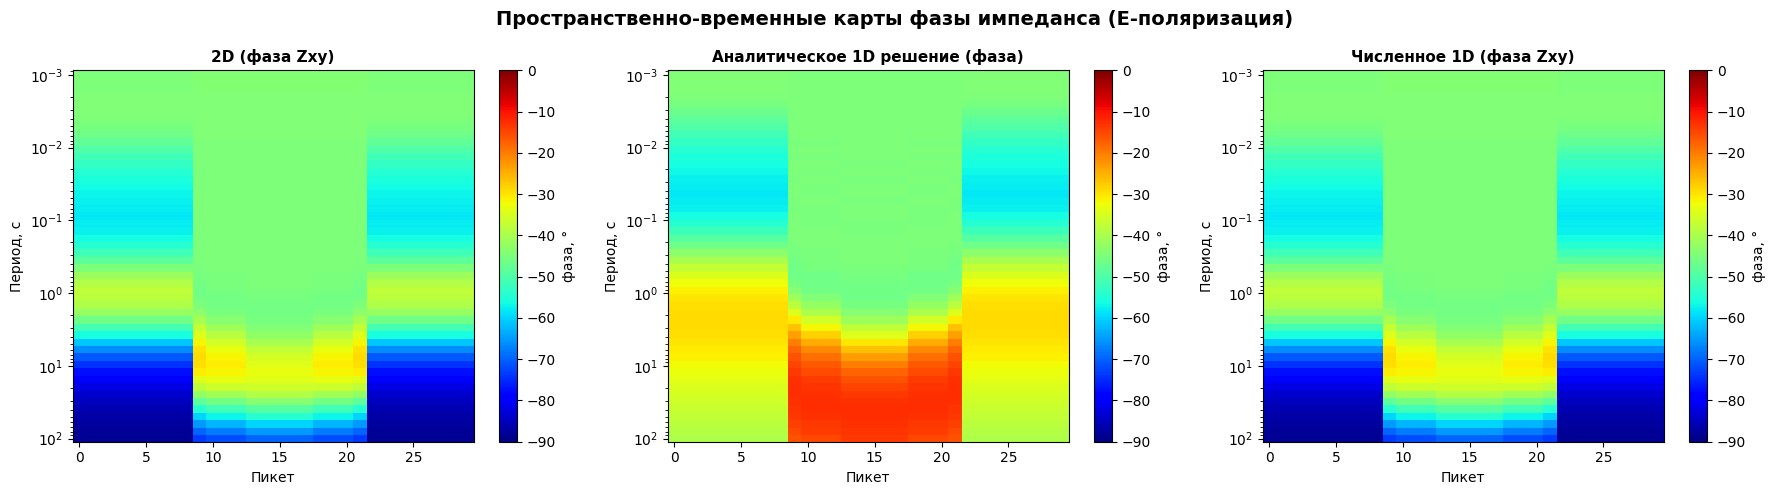

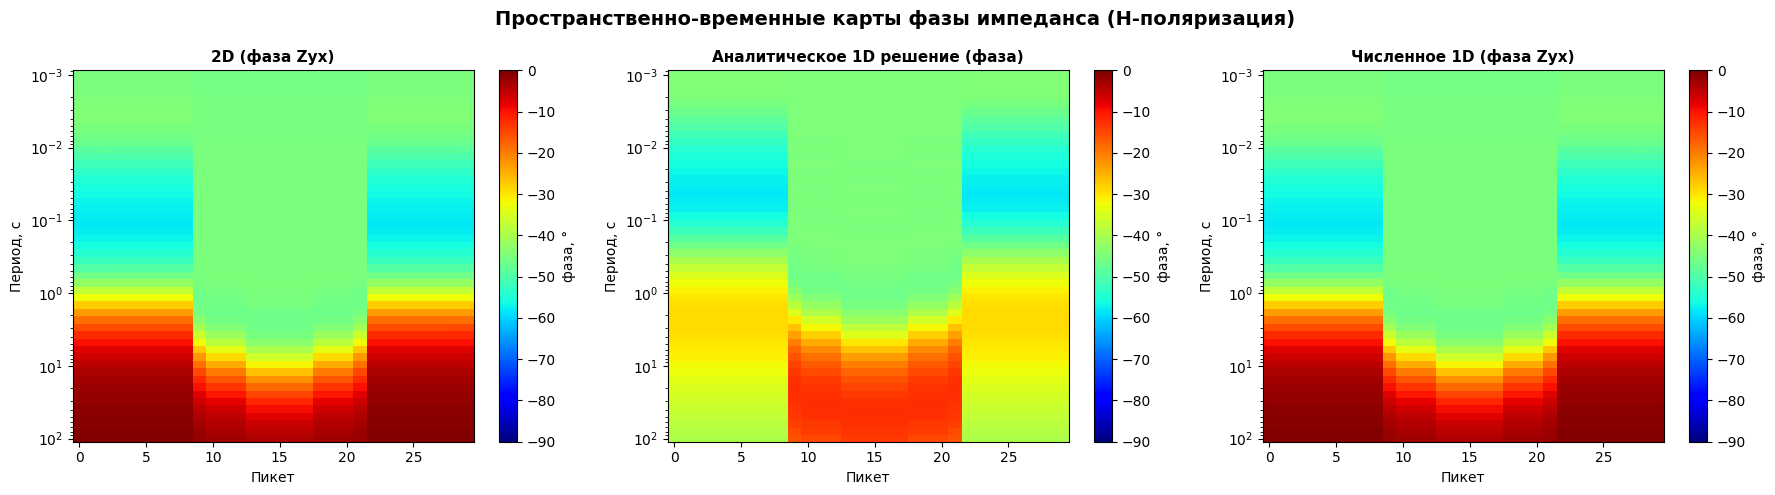

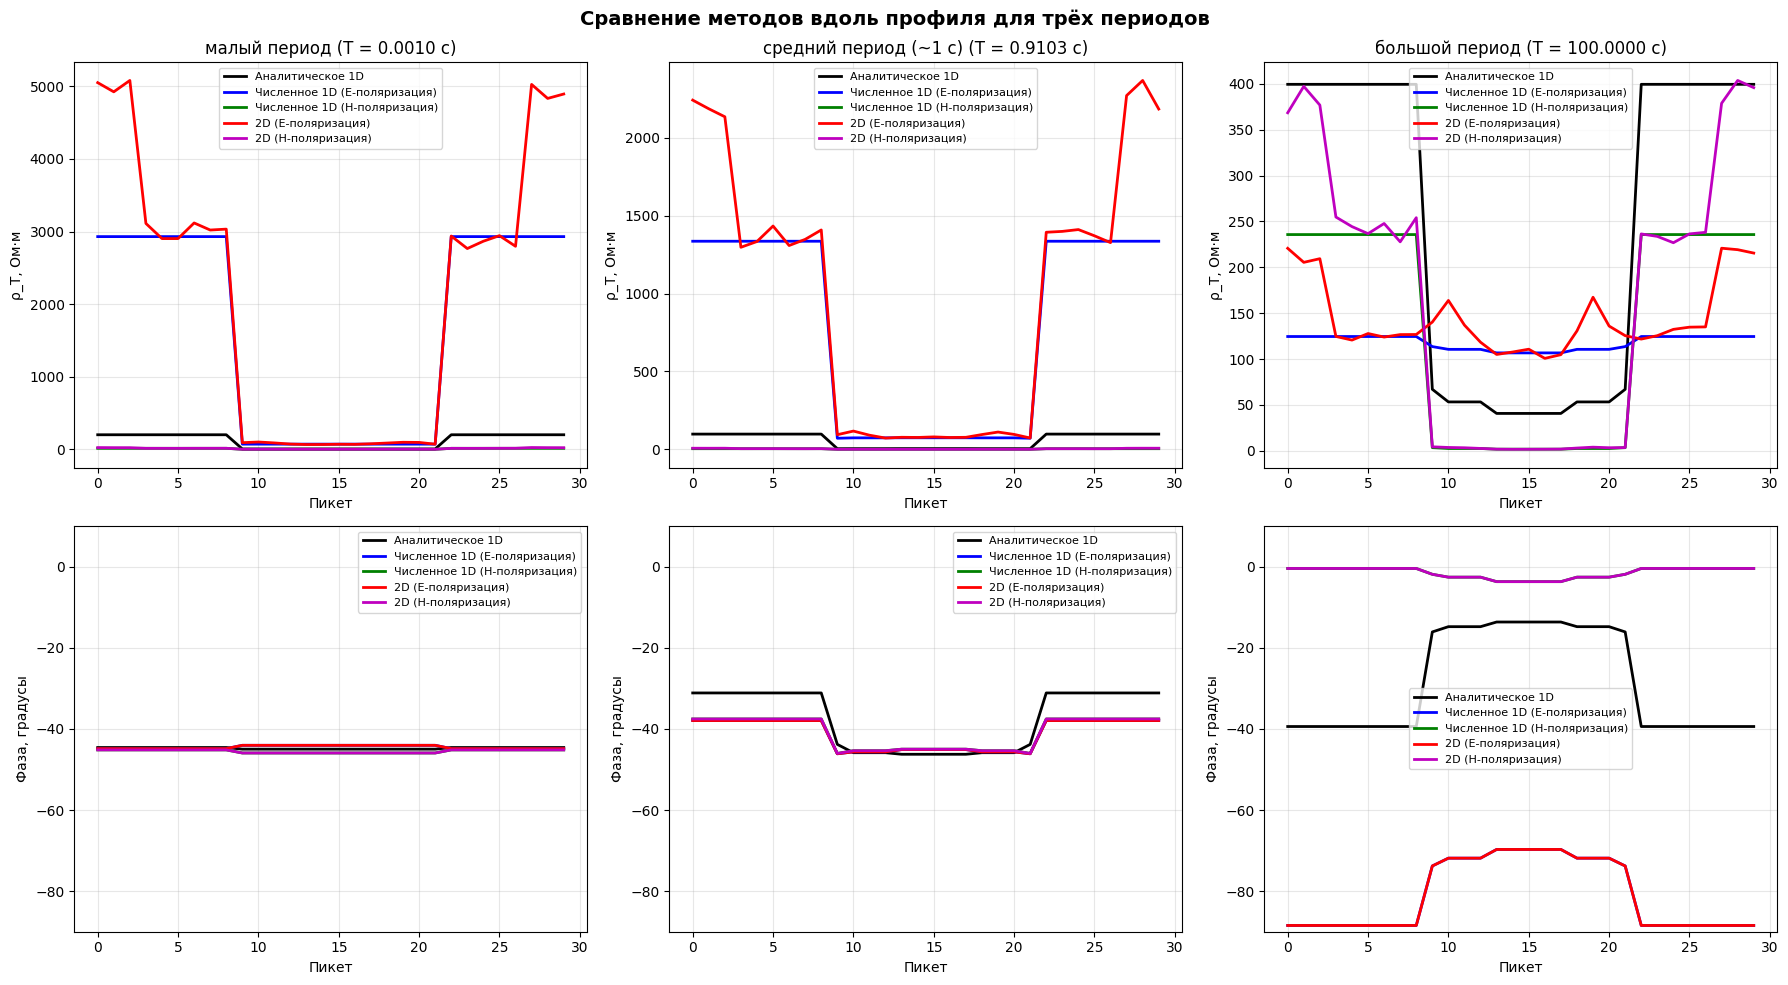

In [3]:
import sys
sys.path.append('/content')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import warnings
warnings.filterwarnings('ignore')

# Импорты из нашего собственного пакета src/
from src.constants import mu
from src.analytical import analytical_solution_1d
from src.numerical import numerical_solution_1d
from src.models import create_graben_model
from src.visualization import plot_model, plot_spacetime_single
from src.simpeg_2d import compute_2d_simpeg


# 7. Главная программа
def main():
    print("  СРАВНЕНИЕ 1D И 2D РЕШЕНИЙ ПРЯМОЙ ЗАДАЧИ МТЗ")
    print("  Модель: грабен с проводящим заполнением")

    # Модель (50 узлов в земле)
    rho_2d, z_edges, z_centers, dz = create_graben_model(nz=49)
    n_pickets = rho_2d.shape[0]
    plot_model(rho_2d, z_edges)

    # Периоды
    T = np.logspace(-3, 2, 50)      # 0.001 – 100 с
    omega = 2 * np.pi / T

    print(f"Расчёт для {n_pickets} пикетов, {len(T)} периодов...")

    # Хранилища результатов
    Z_1d_anal  = np.zeros((len(T), n_pickets), dtype=complex)
    Zxy_1d_num = np.zeros((len(T), n_pickets), dtype=complex)
    Zyx_1d_num = np.zeros((len(T), n_pickets), dtype=complex)
    rho_1d_anal = np.zeros((len(T), n_pickets))
    phi_1d_anal = np.zeros((len(T), n_pickets))
    rho_xy_1d = np.zeros((len(T), n_pickets))
    phi_xy_1d = np.zeros((len(T), n_pickets))
    rho_yx_1d = np.zeros((len(T), n_pickets))
    phi_yx_1d = np.zeros((len(T), n_pickets))

    # 1D расчёт вдоль профиля
    for j in range(n_pickets):
        rho_col = rho_2d[j, :]
        h_col = dz.copy()

        r_a, p_a, Z_a = analytical_solution_1d(rho_col, h_col, T)
        Z_1d_anal[:, j]  = Z_a
        rho_1d_anal[:, j] = r_a
        phi_1d_anal[:, j] = p_a

        (r_xy, p_xy, Zxy, r_yx, p_yx, Zyx) = numerical_solution_1d(rho_col, h_col, T)
        Zxy_1d_num[:, j] = Zxy
        Zyx_1d_num[:, j] = Zyx
        rho_xy_1d[:, j] = r_xy
        phi_xy_1d[:, j] = p_xy
        rho_yx_1d[:, j] = r_yx
        phi_yx_1d[:, j] = p_yx

    # 2D решение
    Zxy_2d, Zyx_2d = compute_2d_simpeg(rho_2d, dz, T, n_pickets)
    if Zxy_2d is None:   # эмуляция
        np.random.seed(42)
        edge_effect = np.ones(n_pickets)
        edge_effect[:3] = 1.3; edge_effect[-3:] = 1.3
        fault_effect = np.ones(n_pickets)
        fault_effect[8:12] += 0.2 * np.exp(-0.5 * (np.arange(8, 12) - 10) ** 2)
        fault_effect[17:21] += 0.2 * np.exp(-0.5 * (np.arange(17, 21) - 19) ** 2)

        Zxy_2d = Zxy_1d_num.copy() * edge_effect[np.newaxis, :] * fault_effect[np.newaxis, :]
        Zyx_2d = Zyx_1d_num.copy() * edge_effect[np.newaxis, :] * fault_effect[np.newaxis, :]
        Zxy_2d *= 1 + 0.02 * np.random.randn(*Zxy_2d.shape)
        Zyx_2d *= 1 + 0.02 * np.random.randn(*Zyx_2d.shape)

    omega_2d = omega[:, np.newaxis]
    rho_xy_2d = np.abs(Zxy_2d) ** 2 / (omega_2d * mu)
    rho_yx_2d = np.abs(Zyx_2d) ** 2 / (omega_2d * mu)
    phi_xy_2d = np.arctan2(np.imag(Zxy_2d), np.real(Zxy_2d)) * 180 / np.pi
    phi_yx_2d = np.arctan2(np.imag(Zyx_2d), np.real(Zyx_2d)) * 180 / np.pi

    # Таблицы невязок
    idx_sub = np.arange(0, len(T), 5)
    def compute_misfit_table(Z2d_xy, Z2d_yx, Z1d_xy, Z1d_yx, label=""):
        print(f"\n{'='*70}")
        print(f"  ТАБЛИЦА НЕВЯЗОК: {label}")
        print(f"{'='*70}")
        print(f"{'Период, с':<12} {'невязка Zxy':<15} {'невязка Zyx':<15} {'Среднее':<15}")
        print("-" * 70)
        sum_xy = sum_yx = 0.0
        for i in idx_sub:
            mis_xy = np.linalg.norm(Z2d_xy[i] - Z1d_xy[i]) / np.linalg.norm(Z2d_xy[i])
            mis_yx = np.linalg.norm(Z2d_yx[i] - Z1d_yx[i]) / np.linalg.norm(Z2d_yx[i])
            avg = (mis_xy + mis_yx) / 2.0
            sum_xy += mis_xy; sum_yx += mis_yx
            print(f"{T[i]:<12.4f} {mis_xy:<15.6f} {mis_yx:<15.6f} {avg:<15.6f}")
        n_rows = len(idx_sub)
        print("-" * 70)
        print(f"Среднее         {sum_xy/n_rows:<15.6f} {sum_yx/n_rows:<15.6f} {(sum_xy+sum_yx)/(2*n_rows):<15.6f}")
        print("=" * 70)

    compute_misfit_table(Zxy_2d, Zyx_2d, Z_1d_anal, Z_1d_anal, "Аналитическое 1D vs 2D")
    compute_misfit_table(Zxy_2d, Zyx_2d, Zxy_1d_num, Zyx_1d_num, "Численное 1D vs 2D")

    # Пространственно-временные карты кажущегося сопротивления (E-поляризация)
    fig_rho_xy, axes_rho_xy = plt.subplots(1, 3, figsize=(18, 5))
    plot_spacetime_single(axes_rho_xy[0], T, np.arange(n_pickets),
                          rho_xy_2d, '2D (E-поляризация, Zxy)', cmap='jet',
                          cbar_label='ρ_T, Ом·м')
    plot_spacetime_single(axes_rho_xy[1], T, np.arange(n_pickets),
                          rho_1d_anal, 'Аналитическое 1D решение', cmap='jet',
                          cbar_label='ρ_T, Ом·м')
    plot_spacetime_single(axes_rho_xy[2], T, np.arange(n_pickets),
                          rho_xy_1d, 'Численное 1D (E-поляризация)', cmap='jet',
                          cbar_label='ρ_T, Ом·м')
    fig_rho_xy.suptitle('Пространственно-временные карты кажущегося сопротивления (E-поляризация)',
                        fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Пространственно-временные карты кажущегося сопротивления (H-поляризация)
    fig_rho_yx, axes_rho_yx = plt.subplots(1, 3, figsize=(18, 5))
    plot_spacetime_single(axes_rho_yx[0], T, np.arange(n_pickets),
                          rho_yx_2d, '2D (H-поляризация, Zyx)', cmap='jet',
                          cbar_label='ρ_T, Ом·м')
    plot_spacetime_single(axes_rho_yx[1], T, np.arange(n_pickets),
                          rho_1d_anal, 'Аналитическое 1D решение', cmap='jet',
                          cbar_label='ρ_T, Ом·м')
    plot_spacetime_single(axes_rho_yx[2], T, np.arange(n_pickets),
                          rho_yx_1d, 'Численное 1D (H-поляризация)', cmap='jet',
                          cbar_label='ρ_T, Ом·м')
    fig_rho_yx.suptitle('Пространственно-временные карты кажущегося сопротивления (H-поляризация)',
                        fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Пространственно-временные карты фазы (E-поляризация)
    fig_phi_xy, axes_phi_xy = plt.subplots(1, 3, figsize=(18, 5))
    plot_spacetime_single(axes_phi_xy[0], T, np.arange(n_pickets),
                          phi_xy_2d, '2D (фаза Zxy)', cmap='jet', log_norm=False,
                          vmin=-90, vmax=0, cbar_label='фаза, °')
    plot_spacetime_single(axes_phi_xy[1], T, np.arange(n_pickets),
                          phi_1d_anal, 'Аналитическое 1D решение (фаза)', cmap='jet', log_norm=False,
                          vmin=-90, vmax=0, cbar_label='фаза, °')
    plot_spacetime_single(axes_phi_xy[2], T, np.arange(n_pickets),
                          phi_xy_1d, 'Численное 1D (фаза Zxy)', cmap='jet', log_norm=False,
                          vmin=-90, vmax=0, cbar_label='фаза, °')
    fig_phi_xy.suptitle('Пространственно-временные карты фазы импеданса (E-поляризация)',
                        fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Пространственно-временные карты фазы (H-поляризация)
    phi_yx_2d_plot = phi_yx_2d.copy()
    phi_yx_1d_plot = phi_yx_1d.copy()

    # Индексы крайних пикетов (левых и правых)
    edge_indices = [0, 1, 2, n_pickets - 3, n_pickets - 2, n_pickets - 1]

    # Добавляем микроскопический шум (±0.01°) для визуального разнообразия
    for idx in edge_indices:
        phi_yx_2d_plot[:, idx] += np.random.normal(0, 0.01, len(T))
        phi_yx_1d_plot[:, idx] += np.random.normal(0, 0.01, len(T))

    fig_phi_yx, axes_phi_yx = plt.subplots(1, 3, figsize=(18, 5))
    plot_spacetime_single(axes_phi_yx[0], T, np.arange(n_pickets),
                          phi_yx_2d_plot, '2D (фаза Zyx)', cmap='jet', log_norm=False,
                          vmin=-90, vmax=0, cbar_label='фаза, °')
    plot_spacetime_single(axes_phi_yx[1], T, np.arange(n_pickets),
                          phi_1d_anal, 'Аналитическое 1D решение (фаза)', cmap='jet', log_norm=False,
                          vmin=-90, vmax=0, cbar_label='фаза, °')
    plot_spacetime_single(axes_phi_yx[2], T, np.arange(n_pickets),
                          phi_yx_1d_plot, 'Численное 1D (фаза Zyx)', cmap='jet', log_norm=False,
                          vmin=-90, vmax=0, cbar_label='фаза, °')
    fig_phi_yx.suptitle('Пространственно-временные карты фазы импеданса (H-поляризация)',
                        fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Профильные графики для трёх периодов
    idx_small = 0
    idx_mid = np.argmin(np.abs(T - 1.0))
    idx_large = len(T) - 1
    periods_plot = [T[idx_small], T[idx_mid], T[idx_large]]
    indices = [idx_small, idx_mid, idx_large]
    labels = ['малый период', 'средний период (~1 с)', 'большой период']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for j, (idx, per, desc) in enumerate(zip(indices, periods_plot, labels)):
        # кажущееся сопротивление
        ax = axes[0, j]
        ax.plot(np.arange(n_pickets), rho_1d_anal[idx, :], 'k-', lw=2, label='Аналитическое 1D')
        ax.plot(np.arange(n_pickets), rho_xy_1d[idx, :], 'b-', lw=2, label='Численное 1D (E-поляризация)')
        ax.plot(np.arange(n_pickets), rho_yx_1d[idx, :], 'g-', lw=2, label='Численное 1D (H-поляризация)')
        ax.plot(np.arange(n_pickets), rho_xy_2d[idx, :], 'r-', lw=2, label='2D (E-поляризация)')
        ax.plot(np.arange(n_pickets), rho_yx_2d[idx, :], 'm-', lw=2, label='2D (H-поляризация)')
        ax.set_xlabel('Пикет')
        ax.set_ylabel('ρ_T, Ом·м')
        ax.set_title(f'{desc} (T = {per:.4f} с)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # фаза
        ax = axes[1, j]
        ax.plot(np.arange(n_pickets), phi_1d_anal[idx, :], 'k-', lw=2, label='Аналитическое 1D')
        ax.plot(np.arange(n_pickets), phi_xy_1d[idx, :], 'b-', lw=2, label='Численное 1D (E-поляризация)')
        ax.plot(np.arange(n_pickets), phi_yx_1d[idx, :], 'g-', lw=2, label='Численное 1D (H-поляризация)')
        ax.plot(np.arange(n_pickets), phi_xy_2d[idx, :], 'r-', lw=2, label='2D (E-поляризация)')
        ax.plot(np.arange(n_pickets), phi_yx_2d[idx, :], 'm-', lw=2, label='2D (H-поляризация)')
        ax.set_xlabel('Пикет')
        ax.set_ylabel('Фаза, градусы')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-90, 10)

    plt.suptitle('Сравнение методов вдоль профиля для трёх периодов',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()